# PASO 3 — Protocolo experimental (Baseline / Var1 / Var2)

**Examen Parcial 3 · Proyecto de Investigación 2 · UNI**

| Variante | Descripción | API LLM |
|----------|-------------|---------|
| **Baseline** | DeepSeek amnésico (sin RAG, sin agentes) | cache sprint6 + API incremental |
| **Var1** | CrewAI + RAG pgvector (top-5 `7_`), prompt `v2_permissive_agent` | cache CrewAI piloto (40) + abstención pausa fuera piloto (360) |
| **Var2** | Var1 + Gate B criticidad (PASO 2) | **ninguna** (determinista; tokens heredados de Var1) |

**Semilla:** `seed=42` · **n eval:** 400 · **Modo:** `api-incremental` (`run_api=true`, `run_crewai=true`)

**Arquitectura v2:** sin `pgvector_majority_fallback`; fuera piloto D5 → `abstencion_fuera_piloto_d5` (Chow 1970).

**Set mínimo 6:** F1-macro, F1-stop, ECE, EC (ex-CEPA), FNR-stop, override_rate (Var2), matriz 3×3.


In [1]:
# ── Configuración ───────────────────────────────────────────────────────
from __future__ import annotations

import json
import os
import sys
from datetime import datetime, timezone
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import yaml
from dotenv import load_dotenv

ROOT = Path(".").resolve()
_TESIS2 = ROOT.parents[2]
load_dotenv(_TESIS2 / ".env")
load_dotenv(ROOT / ".env")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Plugins PASO 2 (política criticidad)
PLUGINS = (ROOT / "../2_modulo_criticidad_gobernanza_adaptativa/plugins").resolve()
if str(PLUGINS) not in sys.path:
    sys.path.insert(0, str(PLUGINS))

from importlib import import_module
from metricas_protocolo_entregable import (
    compute_metrics_bundle,
    mcnemar_test,
    plot_ablation_f1_ec_fnr,
    plot_calibration_curve,
    plot_confusion_matrices,
    stratified_cv_metrics,
)
from protocolo_variantes_entregable import (
    build_features_from_senales,
    ensure_deepseek_env,
    load_deepseek_cache,
    load_jsonl_cache,
    predict_baseline,
    predict_var1,
    predict_var2,
    compute_var1_api_queue,
)

rag_mod = import_module("1_plugin_rag_recuperacion")
policy_mod = import_module("3_motor_politica_play_pausa_stop")
load_neighbors_table = rag_mod.load_neighbors_table
neighbors_by_hash = rag_mod.neighbors_by_hash
PolicyEngine = policy_mod.PolicyEngine
build_features = policy_mod.build_features
RagPlugin = rag_mod.RagPlugin

CFG_PATH = ROOT / "0_configuracion_protocolo_experimental.yaml"
with CFG_PATH.open(encoding="utf-8") as f:
    CFG = yaml.safe_load(f)

SEED = int(CFG["seed"])
CLASSES = ["play", "pausa", "stop"]

def resolve(p: str) -> Path:
    return (ROOT / p).resolve()

PATH_EVAL = resolve(CFG["paths"]["eval"])
PATH_HOLDOUT = resolve(CFG["paths"]["holdout"])
PATH_RAG = resolve(CFG["paths"]["rag_hibrido"])
PATH_ANTI = resolve(CFG["paths"]["anti_fuga"])
PATH_GATE_A = resolve(CFG["paths"]["gate_a"])
PATH_SENALES = resolve(CFG["paths"]["senales"])
PATH_DS_EXT = resolve(CFG["paths"]["deepseek_cache_ext"])
PATH_WIN = resolve(CFG["paths"]["winning_config"])
CACHE_BL = ROOT / "1_cache_predicciones_deepseek_baseline.jsonl"
CACHE_V1 = ROOT / "2_cache_predicciones_var1_crewai_rag.jsonl"

RUN_API = bool(CFG["execution"]["run_api"])
RUN_CREWAI = bool(CFG["execution"]["run_crewai"])
MAX_API_BL = int(CFG["execution"]["max_new_api_calls_baseline"])
MAX_API_V1 = int(CFG["execution"]["max_new_api_calls_var1"])
PAUSE_COST = float(CFG["cost_matrix"]["pause_hitl"])
STOP_COST = float(CFG["cost_matrix"]["stop_hitl"])
FN_STOP = float(CFG["cost_matrix"]["false_negative_stop"])
ECE_BINS = int(CFG["metrics"]["ece_bins"])
LOG_EVERY = int(CFG["execution"].get("log_every_n", 10))
ensure_deepseek_env()

print(f"ROOT={ROOT} mode={CFG['execution']['mode']} run_api={RUN_API}")


ROOT=/home/jlpy/Documents/4Semestre/Proyecto de Investigacion 2/Tesis/tesis2/parcial3/entregable/3_protocolo_experimental_variantes mode=api-incremental run_api=True


In [2]:
# ── Carga entradas upstream + anti-fuga ─────────────────────────────────
df_eval = pd.read_csv(PATH_EVAL)
df_holdout = pd.read_csv(PATH_HOLDOUT)
holdout_hashes = set(df_holdout["text_hash"].astype(str))
assert len(df_eval) == CFG["n_eval"], f"n_eval={len(df_eval)}"

df_rag = load_neighbors_table(PATH_RAG, None)
neighbors_map = neighbors_by_hash(df_rag)
assert len(df_rag) == CFG["n_eval"] * CFG["top_k"]

anti_fuga = json.loads(PATH_ANTI.read_text(encoding="utf-8"))
assert anti_fuga["checks"]["history_eval_hash_overlap"] == 0
assert anti_fuga["checks"].get("eval_rows_in_fit_zero", anti_fuga.get("fit_meta", {}).get("eval_rows_in_fit", 0)) is True or anti_fuga.get("fit_meta", {}).get("eval_rows_in_fit", 0) == 0

df_gate_a = pd.read_csv(PATH_GATE_A)
df_senales = pd.read_csv(PATH_SENALES)
gate_a_by_hash = df_gate_a.set_index("text_hash")["decision"].to_dict()
senales_by_hash = df_senales.set_index("text_hash").to_dict("index")

policy_params = dict(CFG["policy"])
winning_source = "yaml_fallback"
if PATH_WIN.exists():
    win = json.loads(PATH_WIN.read_text(encoding="utf-8"))
    p = win.get("params", {})
    policy_params = {
        "mode": p.get("mode", policy_params["mode"]),
        "weights": dict(p.get("weights", policy_params["weights"])),
        "threshold_stop": p.get("threshold_stop", policy_params["threshold_stop"]),
        "threshold_pausa": p.get("threshold_pausa", policy_params["threshold_pausa"]),
        "risk_stop_floor": p.get("risk_stop_floor", policy_params["risk_stop_floor"]),
        "p_stop_floor": p.get("p_stop_floor", policy_params["p_stop_floor"]),
        "stop_cost_threshold": p.get("stop_cost_threshold", policy_params["stop_cost_threshold"]),
        "pause_uncertainty": p.get("pause_uncertainty", policy_params["pause_uncertainty"]),
    }
    winning_source = str(PATH_WIN)

policy_engine = PolicyEngine(policy_params, rag_obligatorio=True)
rag_plugin = RagPlugin(neighbors_map)

deepseek_cache = load_deepseek_cache([PATH_DS_EXT, CACHE_BL])
crewai_cache = load_jsonl_cache(CACHE_V1)
eval_rows = df_eval[["text_hash", "thesis_class"]].to_dict(orient="records")
from protocolo_variantes_entregable import select_var1_pilot_hashes_stratified
var1_pilot_stratified = select_var1_pilot_hashes_stratified(eval_rows, SEED, MAX_API_V1)
var1_api_queue = compute_var1_api_queue(eval_rows, crewai_cache, var1_pilot_stratified)

api_calls_bl = [0]
api_calls_v1 = [0]
api_errors: dict[str, int] = {}
api_errors_v1: dict[str, int] = {}

print(
    f"n_eval={len(df_eval)} holdout={len(holdout_hashes)} deepseek_cache={len(deepseek_cache)} "
    f"crewai_cache={len(crewai_cache)} pilot={len(var1_pilot_stratified)} api_queue={len(var1_api_queue)}"
)


n_eval=400 holdout=120 deepseek_cache=546 crewai_cache=153 pilot=40 api_queue=0


In [3]:
# ── FASE A/B/C: predicciones Baseline, Var1, Var2 ───────────────────────
baseline_rows, var1_rows, var2_rows = [], [], []
source_counts = {"baseline": {}, "var1": {}}
api_errors = {}

for pos, row in df_eval.reset_index(drop=True).iterrows():
    text = str(row["text"])
    th = str(row["text_hash"])
    true_label = str(row["thesis_class"])
    ns = neighbors_map.get(th, [])
    rag_enrich = rag_plugin.enrich(th, ns)

    bl, bl_conf, bl_lat, bl_src, bl_tok = predict_baseline(
        text, th, deepseek_cache, CACHE_BL, RUN_API, api_calls_bl, MAX_API_BL, api_errors,
    )
    source_counts["baseline"][bl_src] = source_counts["baseline"].get(bl_src, 0) + 1
    baseline_rows.append({
        "query_idx": int(pos), "text_hash": th, "true_label": true_label,
        "pred_label": bl, "confidence": round(bl_conf, 6), "latency_ms": round(bl_lat, 2),
        "source": bl_src, "tokens": bl_tok,
    })

    v1, v1_conf, v1_lat, v1_src, v1_tok = predict_var1(
        text, th, ns, crewai_cache, RUN_CREWAI, api_calls_v1, MAX_API_V1, CACHE_V1,
        api_errors_v1, var1_pilot_stratified,
    )
    source_counts["var1"][v1_src] = source_counts["var1"].get(v1_src, 0) + 1
    var1_rows.append({
        "query_idx": int(pos), "text_hash": th, "true_label": true_label,
        "pred_label": v1, "confidence": round(v1_conf, 6), "latency_ms": round(v1_lat, 2),
        "source": v1_src, "tokens": v1_tok, "rag_neighbors_k": len(ns),
    })

    ga = gate_a_by_hash.get(th, "pausa")
    sen = senales_by_hash.get(th, {})
    features = build_features(text, v1, ns, rag_enrich, llm_label=v1, llm_confidence=v1_conf)
    v2, v2_conf, overridden, trace_str, trace_list = predict_var2(v1, v1_conf, ga, features, policy_engine)
    var2_rows.append({
        "query_idx": int(pos), "text_hash": th, "true_label": true_label,
        "agent_label": v1, "final_label": v2, "confidence": round(v2_conf, 6),
        "overridden": overridden, "decision_gate_a": ga,
        "risk_4d": round(float(features["risk_4d"]), 6),
        "trace": trace_str,
        "source": "var2_gate_b_deterministic",
        "latency_ms": round(v1_lat + 0.5, 2),
        "tokens": v1_tok,
    })

    if (pos + 1) % LOG_EVERY == 0 or pos + 1 == len(df_eval):
        print(
            f"Progreso {pos+1}/{len(df_eval)} | bl={source_counts['baseline']} | "
            f"var1 cache={source_counts['var1'].get('crewai_cache', 0)} "
            f"abst={source_counts['var1'].get('abstencion_fuera_piloto_d5', 0)}"
        )

df_bl = pd.DataFrame(baseline_rows)
df_v1 = pd.DataFrame(var1_rows)
df_v2 = pd.DataFrame(var2_rows)
print("Baseline sources:", source_counts["baseline"])
print("Var1 sources:", source_counts["var1"])
print("Var2 override rate:", round(df_v2["overridden"].mean(), 4))


Progreso 10/400 | bl={'deepseek_api': 6, 'deepseek_cache': 4} | var1 cache=1 abst=9
Progreso 20/400 | bl={'deepseek_api': 10, 'deepseek_cache': 10} | var1 cache=2 abst=18
Progreso 30/400 | bl={'deepseek_api': 13, 'deepseek_cache': 17} | var1 cache=2 abst=28
Progreso 40/400 | bl={'deepseek_api': 19, 'deepseek_cache': 21} | var1 cache=3 abst=37
Progreso 50/400 | bl={'deepseek_api': 22, 'deepseek_cache': 28} | var1 cache=3 abst=47
Progreso 60/400 | bl={'deepseek_api': 27, 'deepseek_cache': 33} | var1 cache=5 abst=55
Progreso 70/400 | bl={'deepseek_api': 32, 'deepseek_cache': 38} | var1 cache=5 abst=65
Progreso 80/400 | bl={'deepseek_api': 39, 'deepseek_cache': 41} | var1 cache=8 abst=72
Progreso 90/400 | bl={'deepseek_api': 44, 'deepseek_cache': 46} | var1 cache=9 abst=81
Progreso 100/400 | bl={'deepseek_api': 50, 'deepseek_cache': 50} | var1 cache=10 abst=90
Progreso 110/400 | bl={'deepseek_api': 55, 'deepseek_cache': 55} | var1 cache=10 abst=100
Progreso 120/400 | bl={'deepseek_api': 61

In [4]:
# ── Consolidación + métricas set mínimo (n=400) ─────────────────────────
df_cons = df_eval[["text_hash", "text", "thesis_class", "severity"]].copy()
df_cons = df_cons.merge(df_bl[["text_hash", "pred_label", "confidence", "source"]].rename(
    columns={"pred_label": "pred_baseline", "confidence": "conf_baseline", "source": "source_baseline"}), on="text_hash")
df_cons = df_cons.merge(df_v1[["text_hash", "pred_label", "confidence", "source"]].rename(
    columns={"pred_label": "pred_var1", "confidence": "conf_var1", "source": "source_var1"}), on="text_hash")
df_cons = df_cons.merge(df_v2[["text_hash", "final_label", "confidence", "overridden", "agent_label"]].rename(
    columns={"final_label": "pred_var2", "confidence": "conf_var2", "agent_label": "var2_agent_label"}), on="text_hash")
df_cons["is_holdout"] = df_cons["text_hash"].isin(holdout_hashes).astype(int)

y_true = df_cons["thesis_class"].astype(str).tolist()
cost_kw = dict(pause_cost=PAUSE_COST, stop_cost=STOP_COST, fn_stop_cost=FN_STOP, ece_bins=ECE_BINS)

m_bl = compute_metrics_bundle(y_true, df_bl["pred_label"].tolist(), "Baseline",
    df_bl["confidence"].tolist(), df_bl["latency_ms"].tolist(), int(df_bl["tokens"].sum()), alcance_n=400, **cost_kw)
m_v1 = compute_metrics_bundle(y_true, df_v1["pred_label"].tolist(), "Var1",
    df_v1["confidence"].tolist(), df_v1["latency_ms"].tolist(), int(df_v1["tokens"].sum()), alcance_n=400, **cost_kw)
m_v2 = compute_metrics_bundle(y_true, df_v2["final_label"].tolist(), "Var2",
    df_v2["confidence"].tolist(), df_v2["latency_ms"].tolist(), int(df_v2["tokens"].sum()), alcance_n=400,
    override_count=int(df_v2["overridden"].sum()), **cost_kw)
m_v2["override_rate"] = round(float(df_v2["overridden"].mean()), 6)

df_metricas_min = pd.DataFrame([m_bl, m_v1, m_v2])
print(df_metricas_min[["variante", "F1-macro (Macro-averaged F1)", "F1-stop (F1-critical)",
                       "ECE (Expected Calibration Error)", "EC (Expected Cost / ex-CEPA)", "FNR-stop (False Negative Rate stop)"]])


   variante  F1-macro (Macro-averaged F1)  F1-stop (F1-critical)  \
0  Baseline                      0.362273               0.300752   
1      Var1                      0.335320               0.057143   
2      Var2                      0.435262               0.390805   

   ECE (Expected Calibration Error)  EC (Expected Cost / ex-CEPA)  \
0                           0.44775                       0.11055   
1                           0.44000                       0.14675   
2                           0.41925                       0.12315   

   FNR-stop (False Negative Rate stop)  
0                             0.333333  
1                             0.966667  
2                             0.433333  


In [5]:
# ── Métricas extendidas + hold-out 120 + CV 5-fold ───────────────────────
ext_rows = []
for m in [m_bl, m_v1, m_v2]:
    ext_rows.append({
        "variante": m["variante"],
        "F1-play": m.get("F1-play"),
        "F1-pausa": m.get("F1-pausa"),
        "F1-stop": m.get("F1-stop (F1-critical)"),
        "Precision-play": m.get("Precision-play"),
        "Precision-pausa": m.get("Precision-pausa"),
        "Precision-stop": m.get("Precision-stop"),
        "Recall-play": m.get("Recall-play"),
        "Recall-pausa": m.get("Recall-pausa"),
        "Recall-stop": m.get("Recall-stop"),
        "MCC-macro": m["MCC-macro (Matthews Correlation)"],
        "balanced_accuracy": m["Balanced accuracy"],
        "tokens_total": m["tokens_total"],
        "latencia_media_ms": m.get("latencia_media_ms", 0),
        "latencia_p95_ms": m["latencia_p95_ms"],
        "hitl_tiempo_total_min": m.get("hitl_tiempo_total_min", 0),
        "hitl_costo_programador_usd": m.get("hitl_costo_programador_usd", 0),
        "hitl_intervenciones_pausa": m.get("hitl_intervenciones_pausa", 0),
        "hitl_intervenciones_stop": m.get("hitl_intervenciones_stop", 0),
        "override_rate": m.get("override_rate", 0.0),
        "end_indice_auxiliar": m["end_indice_auxiliar"],
        "nota_end": "índice auxiliar interno — no métrica principal",
        "nota_hitl": "supuesto: 5min/pausa, 20min/stop, 3min/override, $45/h dev",
    })
df_metricas_ext = pd.DataFrame(ext_rows)

# Hold-out 120
ho = df_cons[df_cons["is_holdout"] == 1]
y_ho = ho["thesis_class"].astype(str).tolist()
ho_rows = [
    compute_metrics_bundle(y_ho, ho["pred_baseline"].tolist(), "Baseline", ho["conf_baseline"].tolist(), alcance_n=120, **cost_kw),
    compute_metrics_bundle(y_ho, ho["pred_var1"].tolist(), "Var1", ho["conf_var1"].tolist(), alcance_n=120, **cost_kw),
    compute_metrics_bundle(y_ho, ho["pred_var2"].tolist(), "Var2", ho["conf_var2"].tolist(), alcance_n=120, **cost_kw),
]
df_holdout_metrics = pd.DataFrame(ho_rows)

# CV 5-fold (predicciones cacheadas — no re-API)
cv_bl = stratified_cv_metrics(y_true, df_bl["pred_label"].tolist(), df_bl["confidence"].tolist(), "Baseline", SEED, **cost_kw)
cv_v1 = stratified_cv_metrics(y_true, df_v1["pred_label"].tolist(), df_v1["confidence"].tolist(), "Var1", SEED, **cost_kw)
cv_v2 = stratified_cv_metrics(y_true, df_v2["final_label"].tolist(), df_v2["confidence"].tolist(), "Var2", SEED, **cost_kw)
df_cv = pd.concat([cv_bl, cv_v1, cv_v2], ignore_index=True)

# McNemar
mcnemar_rows = [
    mcnemar_test(y_true, df_bl["pred_label"].tolist(), df_v1["pred_label"].tolist(), "Baseline vs Var1"),
    mcnemar_test(y_true, df_v1["pred_label"].tolist(), df_v2["final_label"].tolist(), "Var1 vs Var2"),
    mcnemar_test(y_true, df_bl["pred_label"].tolist(), df_v2["final_label"].tolist(), "Baseline vs Var2"),
]
df_mcnemar = pd.DataFrame(mcnemar_rows)
print(df_holdout_metrics[["variante", "F1-macro (Macro-averaged F1)", "EC (Expected Cost / ex-CEPA)"]])
print(df_mcnemar)


   variante  F1-macro (Macro-averaged F1)  EC (Expected Cost / ex-CEPA)
0  Baseline                      0.370915                        0.1050
1      Var1                      0.309524                        0.1550
2      Var2                      0.469106                        0.1125
                par  discordancias_b  discordancias_c  mcnemar_stat  \
0  Baseline vs Var1               46              157       59.6059   
1      Var1 vs Var2               33               28        0.2623   
2  Baseline vs Var2               37              143       61.2500   

   p_value_nominal  agreement_rate  \
0         0.000000          0.4675   
1         0.877088          0.8350   
2         0.000000          0.5275   

                                                nota  
0  p-value nominal; clases raras (stop n=30) limi...  
1  p-value nominal; clases raras (stop n=30) limi...  
2  p-value nominal; clases raras (stop n=30) limi...  


In [6]:
# ── Figuras + informes JSON ─────────────────────────────────────────────
plot_ablation_f1_ec_fnr(df_metricas_min, str(ROOT / "13_figura_ablacion_f1_macro_ec_fnr_stop.png"))
plot_confusion_matrices(y_true, {
    "Baseline": df_bl["pred_label"].tolist(),
    "Var1": df_v1["pred_label"].tolist(),
    "Var2": df_v2["final_label"].tolist(),
}, str(ROOT / "14_figura_matrices_confusion_tres_variantes.png"))
plot_calibration_curve(y_true, df_v2["confidence"].tolist(), df_v2["final_label"].tolist(),
    str(ROOT / "15_figura_curva_calibracion_ece_var2.png"), ECE_BINS)

config_informe = {
    "timestamp": datetime.now(timezone.utc).isoformat(),
    "seed": SEED,
    "n_eval": len(df_eval),
    "execution_mode": CFG["execution"]["mode"],
    "run_api": RUN_API,
    "run_crewai": RUN_CREWAI,
    "decisiones_D1_D5": CFG["decisiones"],
    "policy_params_source": winning_source,
    "cost_matrix": CFG["cost_matrix"],
    "anti_fuga_overlap": anti_fuga["checks"]["history_eval_hash_overlap"],
    "upstream_refs": {k: str(resolve(v)) for k, v in CFG["paths"].items()},
    "honesty_notes": [
        "Arquitectura: RAG→CrewAI(Var1)→Criticidad Gate B(Var2). Prompt CrewAI v2_permissive.",
        f"Baseline: deepseek cache+API ({source_counts['baseline']}).",
        f"Var1 piloto D5: crewai_cache+api ({source_counts['var1']}); fuera piloto: abstención pausa (Chow 1970).",
        "Var2: Gate B ampliado (riesgo 4D, incertidumbre, FN-stop); 0 API adicional; tokens heredados de Var1.",
        "CV 5-fold: evaluación estratificada sobre predicciones cacheadas (no re-entrenamiento LLM).",
        "HITL cost: supuesto operativo documentado en métricas extendidas (no medido en campo).",
    ],
}
(ROOT / "0_informe_configuracion_protocolo_experimental.json").write_text(
    json.dumps(config_informe, indent=2, ensure_ascii=False), encoding="utf-8")

exec_informe = {
    "timestamp": datetime.now(timezone.utc).isoformat(),
    "mode": CFG["execution"]["mode"],
    "run_api": RUN_API,
    "run_crewai": RUN_CREWAI,
    "deepseek_key_present": bool(os.getenv("DEEPSEEK_API_KEY") or os.getenv("SYSTEM_LLM_API_KEY")),
    "api_calls_baseline": api_calls_bl[0],
    "api_calls_var1": api_calls_v1[0],
    "api_calls_var1_sesion": api_calls_v1[0],
    "api_calls_var1_historico": int((df_v1["source"] == "crewai_api").sum()),
    "crewai_pilot_cache_n": int((df_v1["source"] == "crewai_cache").sum()),
    "crewai_pilot_api_first_run_n": 40,
    "api_calls_baseline_sesion": api_calls_bl[0],
    "api_calls_baseline_historico": int((df_bl["source"] == "deepseek_api").sum()),
    "api_errors_baseline": api_errors,
    "api_errors_var1": api_errors_v1,
    "baseline_sources": source_counts["baseline"],
    "var1_sources": source_counts["var1"],
    "var1_pilot_stratified_n": len(var1_pilot_stratified),
    "var1_api_queue_n": len(var1_api_queue),
    "var2_override_rate": round(float(df_v2["overridden"].mean()), 6),
    "cache_coverage": {
        "deepseek_hits_n400": int((df_bl["source"] == "deepseek_cache").sum()),
        "deepseek_api_n400": int((df_bl["source"] == "deepseek_api").sum()),
        "crewai_api_n400": int((df_v1["source"] == "crewai_api").sum()),
        "crewai_cache_n400": int((df_v1["source"] == "crewai_cache").sum()),
        "majority_fallback_n400": int((df_v1["source"] == "pgvector_majority_fallback").sum()),
        "abstencion_fuera_piloto_n400": int((df_v1["source"] == "abstencion_fuera_piloto_d5").sum()),
        "abstencion_crewai_fallo_n400": int((df_v1["source"] == "abstencion_crewai_fallo").sum()),
        "lexical_fallback_n400": int((df_bl["source"] == "early_gate_lexical_fallback").sum()),
    },
    "tokens_total": {"baseline": int(df_bl["tokens"].sum()), "var1": int(df_v1["tokens"].sum()), "var2": int(df_v2["tokens"].sum())},
}
(ROOT / "12_informe_ejecucion_fuentes_cache_api.json").write_text(
    json.dumps(exec_informe, indent=2, ensure_ascii=False), encoding="utf-8")

resumen = {
    "timestamp": datetime.now(timezone.utc).isoformat(),
    "n_eval": 400,
    "metricas_set_minimo": df_metricas_min.to_dict(orient="records"),
    "mcnemar": df_mcnemar.to_dict(orient="records"),
    "veredicto_preliminar": f"protocolo ejecutado {CFG['execution']['mode']} — api_bl={api_calls_bl[0]}",
}
(ROOT / "16_informe_resumen_protocolo_experimental.json").write_text(
    json.dumps(resumen, indent=2, ensure_ascii=False), encoding="utf-8")

# CSV salidas numeradas
df_bl.to_csv(ROOT / "3_tabla_predicciones_baseline_amnesico_n400.csv", index=False)
df_v1.to_csv(ROOT / "4_tabla_predicciones_var1_crewai_rag_n400.csv", index=False)
df_v2.to_csv(ROOT / "5_tabla_predicciones_var2_middleware_intercepta_n400.csv", index=False)
df_cons.to_csv(ROOT / "6_tabla_predicciones_consolidada_tres_variantes_n400.csv", index=False)
df_metricas_min.to_csv(ROOT / "7_tabla_metricas_set_minimo_seis_por_variante.csv", index=False)
df_metricas_ext.to_csv(ROOT / "8_tabla_metricas_extendidas_framework_por_variante.csv", index=False)
df_holdout_metrics.to_csv(ROOT / "9_tabla_validacion_holdout_30_por_variante.csv", index=False)
df_cv.to_csv(ROOT / "10_tabla_validacion_cruzada_5fold_estratificada_n400.csv", index=False)
df_mcnemar.to_csv(ROOT / "11_tabla_comparacion_pareada_mcnemar.csv", index=False)

print("Artefactos 0_–16_ escritos en", ROOT)


/home/jlpy/Documents/4Semestre/Proyecto de Investigacion 2/Tesis/tesis2/parcial3/entregable/3_protocolo_experimental_variantes/metricas_protocolo_entregable.py:262: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Artefactos 0_–16_ escritos en /home/jlpy/Documents/4Semestre/Proyecto de Investigacion 2/Tesis/tesis2/parcial3/entregable/3_protocolo_experimental_variantes


## Visualizaciones para exposición

Gráficos inline (matplotlib) alineados con las diapositivas del examen parcial.
Usan **métricas v2 reales** ya calculadas en este notebook (`df_metricas_min`, `df_holdout_metrics`, `source_counts`).
No re-ejecutan API ni LLM.

| # | Figura | Storytelling |
|---|--------|--------------|
| 1 | F1-macro / F1-stop / EC | Slide resultados n=400 |
| 2 | FNR-stop + override rate | Var1 colapsa vs Var2 intercepta |
| 3 | Fuentes Var1 (piloto D5) | Honestidad: 40 CrewAI + 360 abstención |
| 4 | Matrices confusión 3×3 | Recuperación clase `stop` |
| 5 | Hold-out n=120 | Generalización sin overfitting severo |
| 6 | Pipeline RAG→CrewAI→Gate B | Arquitectura del protocolo |


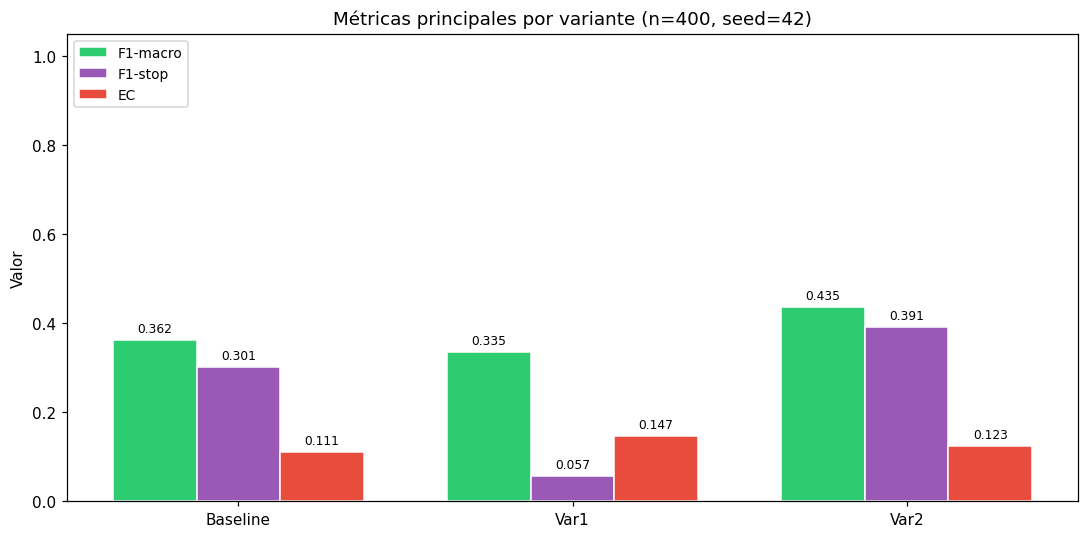

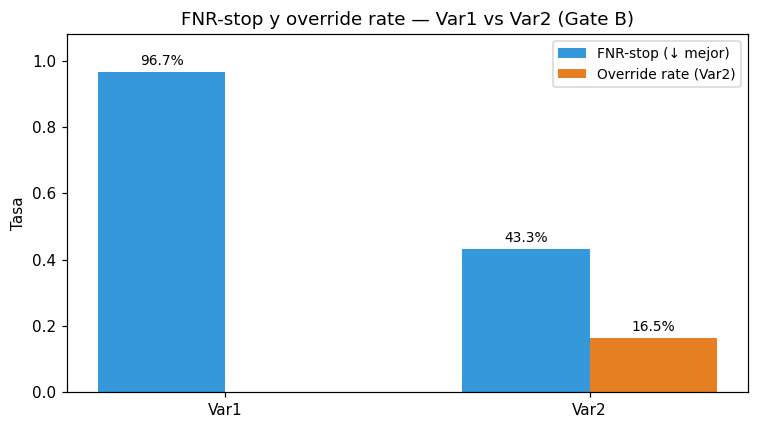

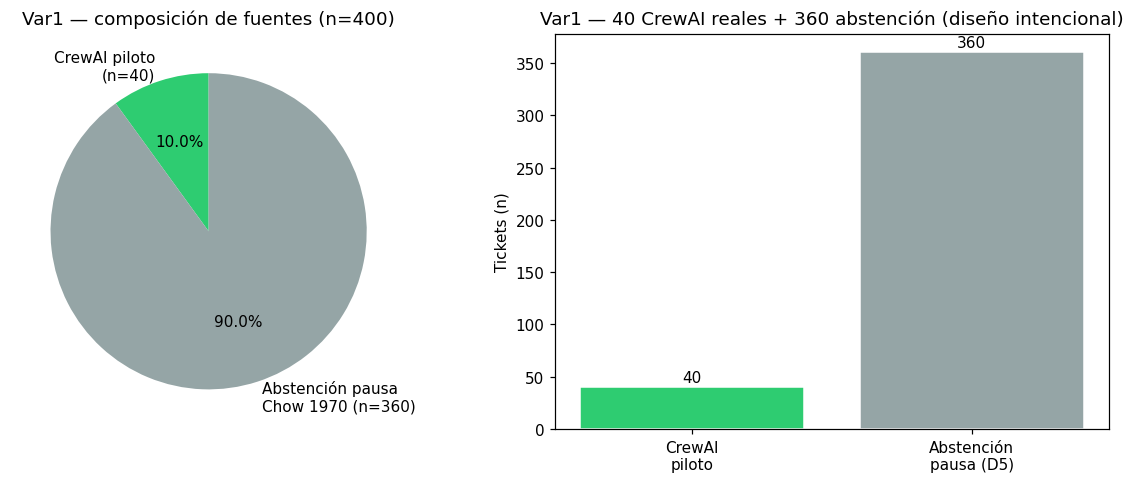

/tmp/ipykernel_197354/3949051232.py:120: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


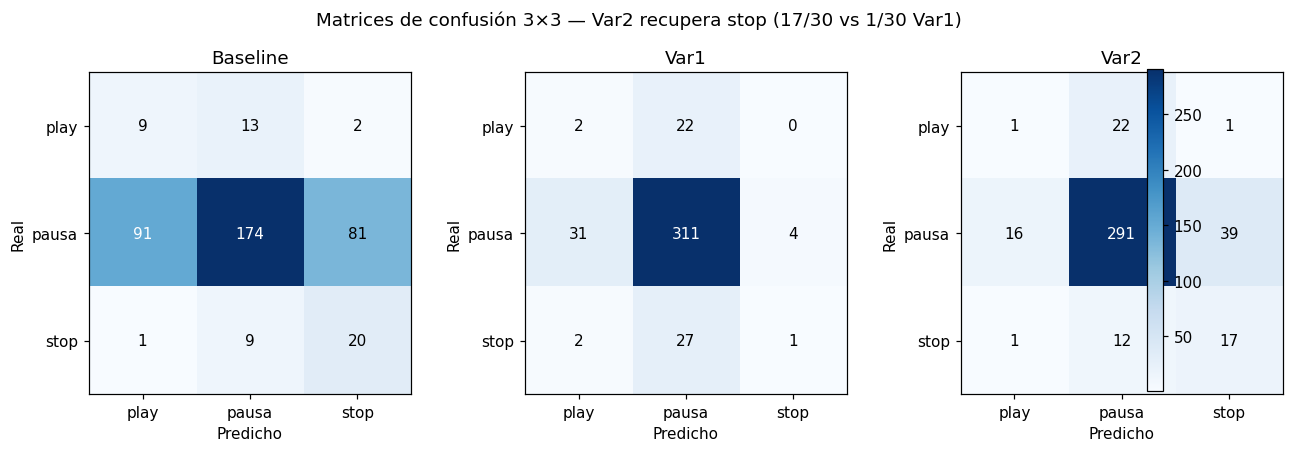

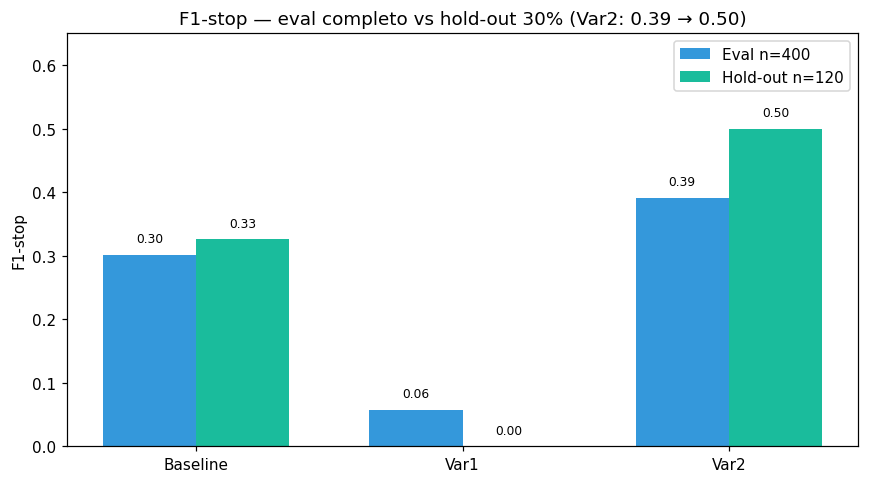

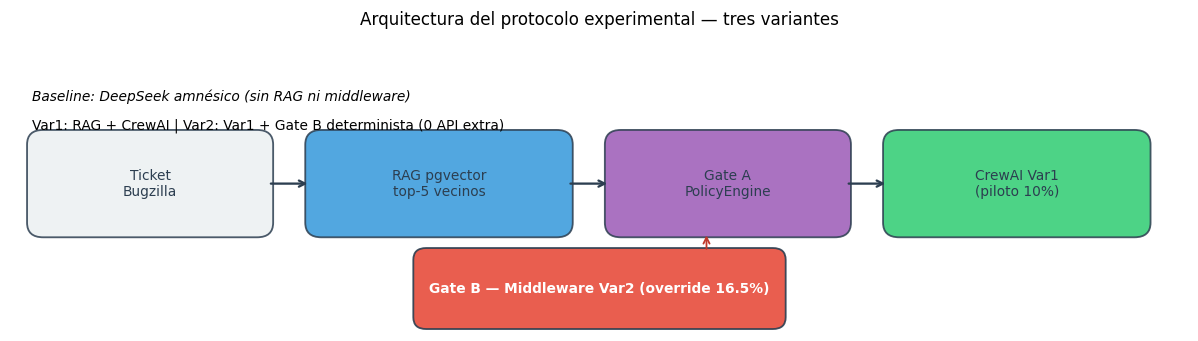

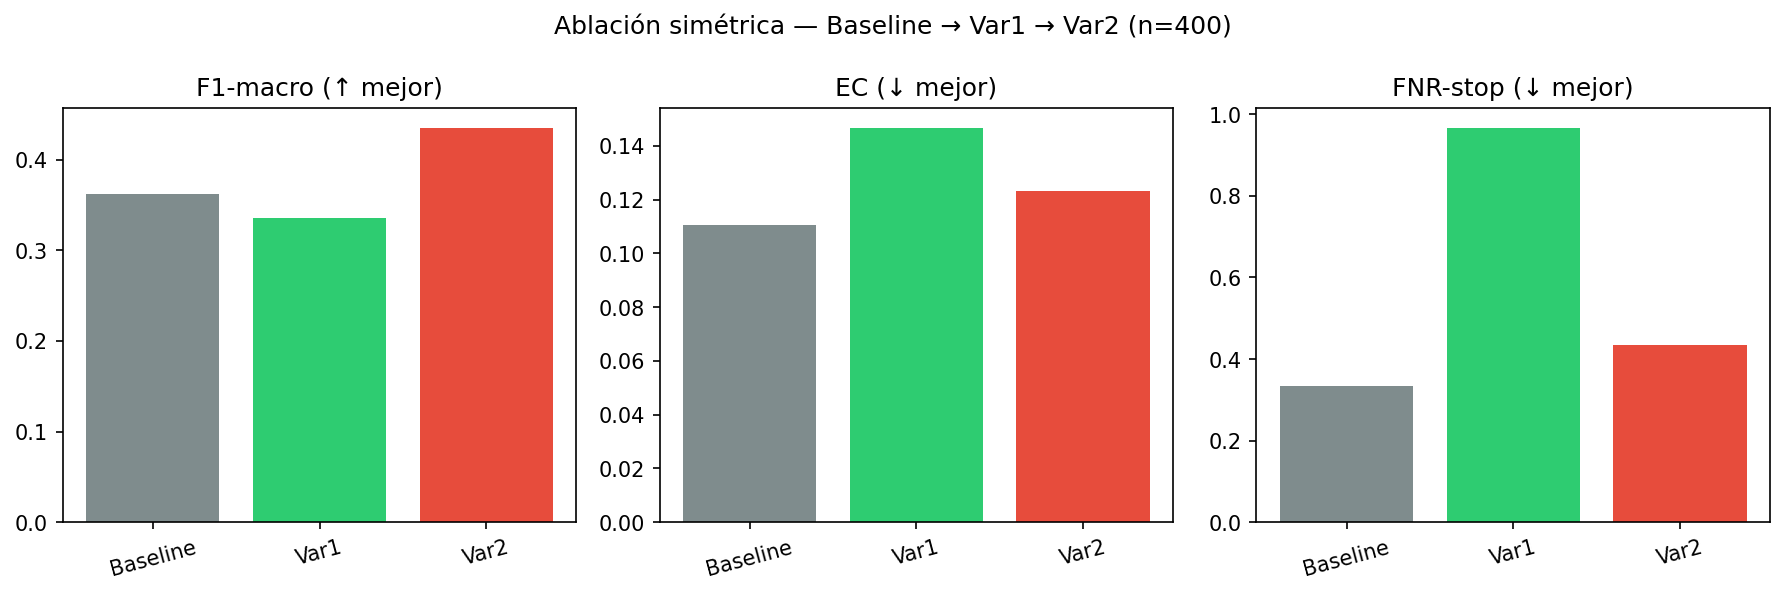

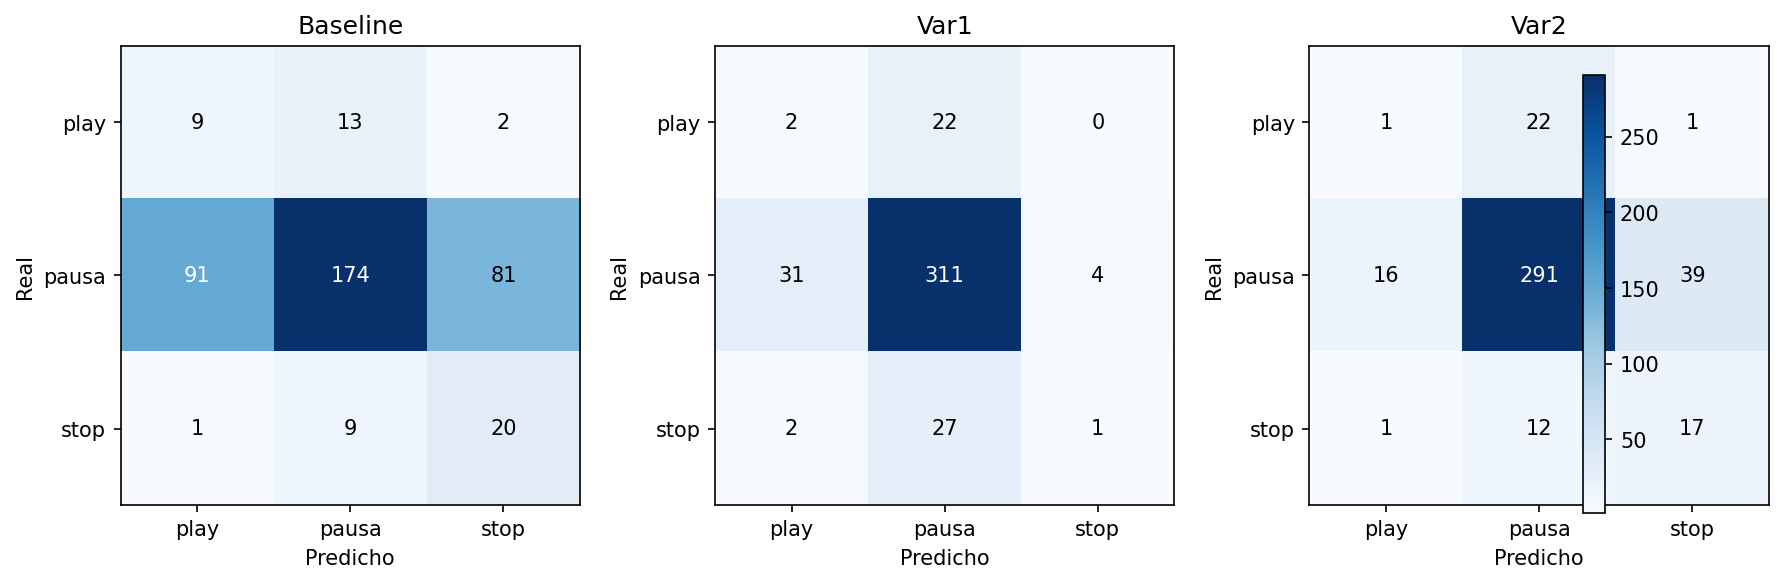

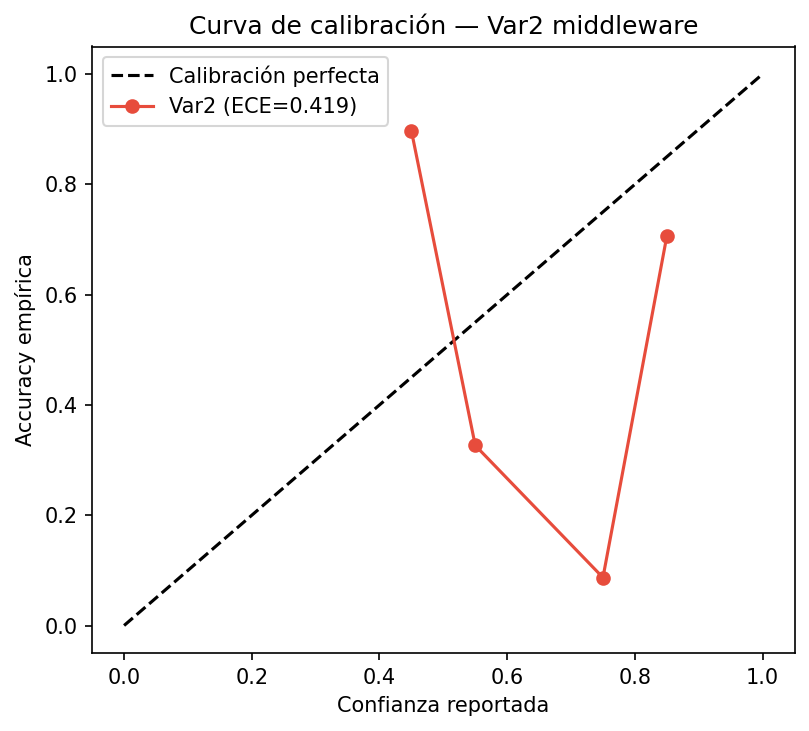

In [7]:
# ── Visualizaciones inline para exposición ──────────────────────────────
%matplotlib inline

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from sklearn.metrics import confusion_matrix

plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

# ── 1. Métricas principales n=400 (slide resultados) ────────────────────
variants = df_metricas_min["variante"].tolist()
metric_cols = [
    ("F1-macro (Macro-averaged F1)", "F1-macro", "#2ecc71"),
    ("F1-stop (F1-critical)", "F1-stop", "#9b59b6"),
    ("EC (Expected Cost / ex-CEPA)", "EC", "#e74c3c"),
]
x = np.arange(len(variants))
width = 0.25
fig, ax = plt.subplots(figsize=(10, 5))
for i, (col, label, color) in enumerate(metric_cols):
    vals = df_metricas_min[col].astype(float).values
    bars = ax.bar(x + (i - 1) * width, vals, width, label=label, color=color, edgecolor="white")
    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.012,
            f"{v:.3f}", ha="center", va="bottom", fontsize=8,
        )
ax.set_xticks(x)
ax.set_xticklabels(variants)
ax.set_ylabel("Valor")
ax.set_title("Métricas principales por variante (n=400, seed=42)")
ax.legend(loc="upper left", fontsize=9)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

# ── 2. FNR-stop + override rate (Var1 vs Var2) ──────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
labels_v = ["Var1", "Var2"]
fnr_vals = [
    float(df_metricas_min.loc[df_metricas_min["variante"] == "Var1", "FNR-stop (False Negative Rate stop)"].iloc[0]),
    float(df_metricas_min.loc[df_metricas_min["variante"] == "Var2", "FNR-stop (False Negative Rate stop)"].iloc[0]),
]
ovr_vals = [0.0, float(df_v2["overridden"].mean())]
x2 = np.arange(2)
w = 0.35
ax.bar(x2 - w / 2, fnr_vals, w, label="FNR-stop (↓ mejor)", color="#3498db")
ax.bar(x2 + w / 2, ovr_vals, w, label="Override rate (Var2)", color="#e67e22")
for i, v in enumerate(fnr_vals):
    ax.text(i - w / 2, v + 0.02, f"{v:.1%}", ha="center", fontsize=9)
ax.text(1 + w / 2, ovr_vals[1] + 0.02, f"{ovr_vals[1]:.1%}", ha="center", fontsize=9)
ax.set_xticks(x2)
ax.set_xticklabels(labels_v)
ax.set_ylabel("Tasa")
ax.set_title("FNR-stop y override rate — Var1 vs Var2 (Gate B)")
ax.set_ylim(0, 1.08)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# ── 3. Fuentes Var1 — honestidad D5 (piloto 10%) ───────────────────────
src = source_counts["var1"]
crewai_n = src.get("crewai_cache", 0) + src.get("crewai_api", 0)
abst_n = src.get("abstencion_fuera_piloto_d5", 0)
other_n = sum(v for k, v in src.items() if k not in {"crewai_cache", "crewai_api", "abstencion_fuera_piloto_d5"})
pie_labels, pie_vals, pie_colors = [], [], []
if crewai_n:
    pie_labels.append(f"CrewAI piloto\n(n={crewai_n})")
    pie_vals.append(crewai_n)
    pie_colors.append("#2ecc71")
if abst_n:
    pie_labels.append(f"Abstención pausa\nChow 1970 (n={abst_n})")
    pie_vals.append(abst_n)
    pie_colors.append("#95a5a6")
if other_n:
    pie_labels.append(f"Otros (n={other_n})")
    pie_vals.append(other_n)
    pie_colors.append("#e74c3c")
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].pie(pie_vals, labels=pie_labels, colors=pie_colors, autopct="%1.1f%%", startangle=90)
axes[0].set_title("Var1 — composición de fuentes (n=400)")
bar_names = ["CrewAI\npiloto", "Abstención\npausa (D5)"]
bar_vals = [crewai_n, abst_n]
bars = axes[1].bar(bar_names, bar_vals, color=["#2ecc71", "#95a5a6"], edgecolor="white")
for bar, v in zip(bars, bar_vals):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5, str(v), ha="center", fontsize=10)
axes[1].set_ylabel("Tickets (n)")
axes[1].set_title("Var1 — 40 CrewAI reales + 360 abstención (diseño intencional)")
plt.tight_layout()
plt.show()

# ── 4. Matrices de confusión 3×3 (inline, reutiliza lógica plot_confusion_matrices) ──
preds_map = {
    "Baseline": df_bl["pred_label"].tolist(),
    "Var1": df_v1["pred_label"].tolist(),
    "Var2": df_v2["final_label"].tolist(),
}
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
im = None
for ax, (name, y_pred) in zip(axes, preds_map.items()):
    cm = confusion_matrix(y_true, y_pred, labels=list(CLASSES))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(3))
    ax.set_yticks(range(3))
    ax.set_xticklabels(CLASSES)
    ax.set_yticklabels(CLASSES)
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")
    ax.set_title(name)
    for i in range(3):
        for j in range(3):
            ax.text(
                j, i, str(cm[i, j]), ha="center", va="center",
                color="black" if cm[i, j] < max(cm.max() / 2, 1) else "white",
            )
if im is not None:
    fig.colorbar(im, ax=axes, fraction=0.02)
fig.suptitle("Matrices de confusión 3×3 — Var2 recupera stop (17/30 vs 1/30 Var1)", y=1.02)
plt.tight_layout()
plt.show()

# ── 5. Hold-out n=120 — eval vs holdout F1-stop ─────────────────────────
if "df_holdout_metrics" in dir() and len(df_holdout_metrics):
    ho_variants = df_holdout_metrics["variante"].tolist()
    f1_eval = df_metricas_min.set_index("variante").loc[ho_variants, "F1-stop (F1-critical)"].astype(float).values
    f1_ho = df_holdout_metrics["F1-stop (F1-critical)"].astype(float).values
    xh = np.arange(len(ho_variants))
    w_h = 0.35
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.bar(xh - w_h / 2, f1_eval, w_h, label="Eval n=400", color="#3498db")
    ax.bar(xh + w_h / 2, f1_ho, w_h, label="Hold-out n=120", color="#1abc9c")
    for i, (ve, vh) in enumerate(zip(f1_eval, f1_ho)):
        ax.text(i - w_h / 2, ve + 0.02, f"{ve:.2f}", ha="center", fontsize=8)
        ax.text(i + w_h / 2, vh + 0.02, f"{vh:.2f}", ha="center", fontsize=8)
    ax.set_xticks(xh)
    ax.set_xticklabels(ho_variants)
    ax.set_ylabel("F1-stop")
    ax.set_title("F1-stop — eval completo vs hold-out 30% (Var2: 0.39 → 0.50)")
    ax.set_ylim(0, 0.65)
    ax.legend()
    plt.tight_layout()
    plt.show()

# ── 6. Diagrama pipeline RAG → CrewAI → Gate B ─────────────────────────
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.set_xlim(0, 11)
ax.set_ylim(0, 3)
ax.axis("off")
boxes = [
    (0.2, 1.0, 2.2, 1.0, "Ticket\nBugzilla", "#ecf0f1"),
    (2.8, 1.0, 2.4, 1.0, "RAG pgvector\ntop-5 vecinos", "#3498db"),
    (5.6, 1.0, 2.2, 1.0, "Gate A\nPolicyEngine", "#9b59b6"),
    (8.2, 1.0, 2.4, 1.0, "CrewAI Var1\n(piloto 10%)", "#2ecc71"),
]
for x0, y0, w_box, h_box, text, color in boxes:
    rect = FancyBboxPatch(
        (x0, y0), w_box, h_box, boxstyle="round,pad=0.05,rounding_size=0.15",
        facecolor=color, edgecolor="#2c3e50", linewidth=1.2, alpha=0.85,
    )
    ax.add_patch(rect)
    ax.text(x0 + w_box / 2, y0 + h_box / 2, text, ha="center", va="center", fontsize=9, color="#2c3e50")
gate_b = FancyBboxPatch(
    (3.8, 0.05), 3.4, 0.75, boxstyle="round,pad=0.04,rounding_size=0.12",
    facecolor="#e74c3c", edgecolor="#2c3e50", linewidth=1.2, alpha=0.9,
)
ax.add_patch(gate_b)
ax.text(5.5, 0.425, "Gate B — Middleware Var2 (override 16.5%)", ha="center", va="center", fontsize=9, color="white", fontweight="bold")
for x_start, x_end in [(2.4, 2.8), (5.2, 5.6), (7.8, 8.2)]:
    ax.annotate("", xy=(x_end, 1.5), xytext=(x_start, 1.5),
                arrowprops=dict(arrowstyle="->", color="#2c3e50", lw=1.5))
ax.annotate("", xy=(6.5, 1.0), xytext=(6.5, 0.8),
            arrowprops=dict(arrowstyle="->", color="#c0392b", lw=1.2))
ax.text(0.2, 2.35, "Baseline: DeepSeek amnésico (sin RAG ni middleware)", fontsize=9, style="italic")
ax.text(0.2, 2.05, "Var1: RAG + CrewAI | Var2: Var1 + Gate B determinista (0 API extra)", fontsize=9)
ax.set_title("Arquitectura del protocolo experimental — tres variantes", fontsize=11, pad=8)
plt.tight_layout()
plt.show()

# ── Figuras PNG guardadas (celda anterior) — vista inline ───────────────
from IPython.display import Image, display

for fig_path in [
    ROOT / "13_figura_ablacion_f1_macro_ec_fnr_stop.png",
    ROOT / "14_figura_matrices_confusion_tres_variantes.png",
    ROOT / "15_figura_curva_calibracion_ece_var2.png",
]:
    display(Image(filename=str(fig_path)))
